In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot") #to make more attractive visuals

In [30]:
# Loading the datasets

train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [31]:
# Basic inspection

print(train_df.shape)
print(test_df.shape)

(100000, 2)
(20000, 2)


In [32]:
print(train_df.info())
    

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   100000 non-null  int64
 1   text    100000 non-null  str  
dtypes: int64(1), str(1)
memory usage: 71.3 MB
None


In [33]:
train_df.describe(include = "all")    #to get summary of every column

,label,text
count,100000.000000,100000
unique,NaN,100000
top,NaN,Good food for a buffet chain. Extensive salad ...
freq,NaN,1
mean,2.000000,NaN
std,1.414221,NaN
min,0.000000,NaN
25%,1.000000,NaN
50%,2.000000,NaN
75%,3.000000,NaN


In [34]:
# checking null values

train_df.isnull().sum()

label    0
text     0
dtype: int64

In [35]:
# Checking duplicates

train_df.duplicated().sum()

np.int64(0)

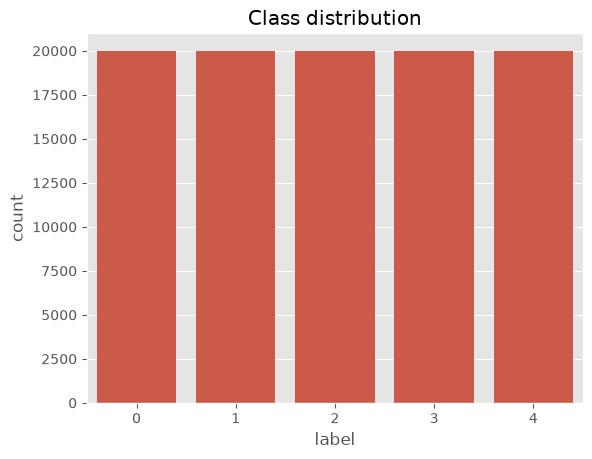

In [36]:
#visualization of class distribution

sns.countplot(
    data = train_df,
    x = "label"
)
plt.title("Class distribution")
plt.show()

In [37]:
# text length analysis

train_df["review_length"] = train_df["text"].str.len()
# .str.len() is a Pandas string method that works element-wise on every value in a Series.

train_df["review_length"].describe()

count    100000.00000
mean        732.10125
std         662.66698
min           1.00000
25%         286.00000
50%         539.00000
75%         959.00000
max        5096.00000
Name: review_length, dtype: float64

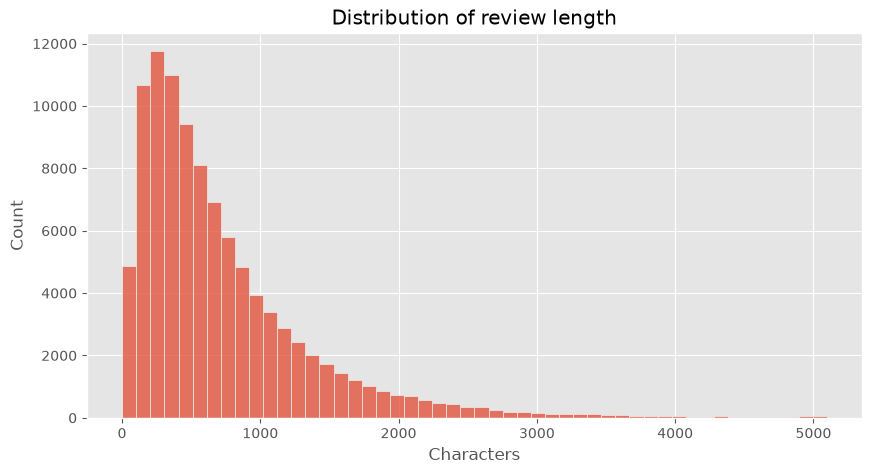

In [38]:
# visualization of text length

plt.figure(figsize = (10, 5))
sns.histplot(train_df["review_length"], bins = 50)
plt.title("Distribution of review length")
plt.xlabel("Characters")
plt.show()

In [39]:
# word count of each review

train_df["word_count"] = train_df["text"].str.split().str.len()

In [40]:
train_df["word_count"].describe()


count    100000.000000
mean        134.030460
std         121.162748
min           1.000000
25%          52.000000
50%          99.000000
75%         176.000000
max        1034.000000
Name: word_count, dtype: float64

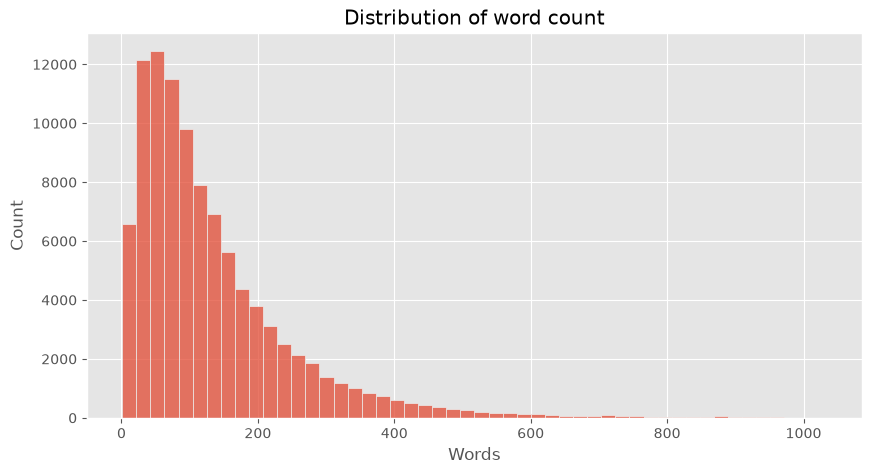

In [41]:
# visualization of word count column

plt.figure(figsize= (10, 5))
sns.histplot(train_df["word_count"], bins = 50)
plt.title("Distribution of word count")
plt.xlabel("Words")
plt.show()

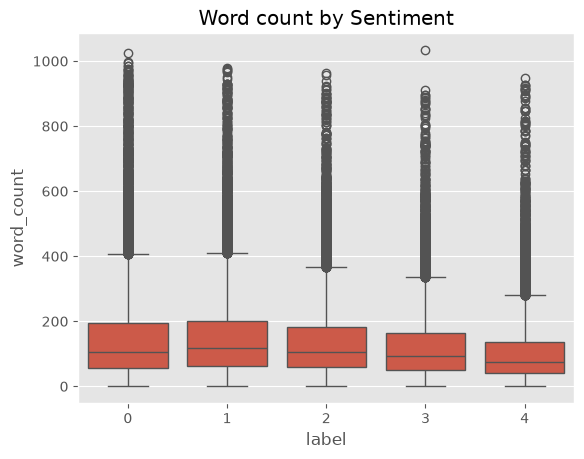

In [42]:
# Review length by class 
# tells whether certain sentiment classes generally have longer reviews

sns.boxplot(
    data = train_df,
    x = "label",
    y = "word_count"
)

plt.title("Word count by Sentiment")
plt.show()

In [43]:
#Most common review lengths

train_df["word_count"].value_counts().head(10)

word_count
48    672
46    666
43    662
50    658
54    652
41    648
45    645
49    633
37    630
60    626
Name: count, dtype: int64

In [45]:
# review of max length

train_df.loc[train_df["word_count"].idxmax()]

label                                                            3
text             We stayed here the weekend of 4/19/13 to 4/21/...
review_length                                                 5003
word_count                                                    1034
Name: 67492, dtype: object

In [46]:
# checking empty reviews

(train_df["text"].str.strip() == "").sum()

np.int64(0)